# Tokenização e PLN

In [34]:

!pip install transformers torch sentencepiece


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
# importações 
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [36]:
# baixa o modelo treinado para indentificar palavras estatisticamente 
nltk.download('punkt')
nltk.download("punkt_tab")

# baixa as stopwords
nltk.download('stopwords')




[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PROG01\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PROG01\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PROG01\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
texto = 'Hoje o dia está lindo.'

tokens = word_tokenize(texto)

print(tokens)

['Hoje', 'o', 'dia', 'está', 'lindo', '.']


#  Letra de musica

In [38]:
with open('letras.txt', 'r', encoding='utf-8') as arquivo:
    letras = arquivo.read()

letra = letras.replace(',', '')    

tokens = word_tokenize(letra.lower(), language='portuguese')    

In [39]:
from nltk import FreqDist
import pandas as pd

In [40]:
frequencia = FreqDist(tokens)
print(f'Total de tokens: {len(tokens)}')
for i,j in frequencia.items():
    print(f'Token: {i:10} | Quantidade: {j}')

Total de tokens: 227
Token: percebo    | Quantidade: 2
Token: que        | Quantidade: 14
Token: o          | Quantidade: 11
Token: tempo      | Quantidade: 2
Token: já         | Quantidade: 2
Token: não        | Quantidade: 9
Token: passa      | Quantidade: 2
Token: você       | Quantidade: 7
Token: diz        | Quantidade: 2
Token: tem        | Quantidade: 2
Token: graça      | Quantidade: 2
Token: amar       | Quantidade: 2
Token: assim      | Quantidade: 2
Token: foi        | Quantidade: 2
Token: tudo       | Quantidade: 5
Token: tão        | Quantidade: 2
Token: bonito     | Quantidade: 2
Token: mas        | Quantidade: 7
Token: voou       | Quantidade: 2
Token: pro        | Quantidade: 2
Token: infinito   | Quantidade: 2
Token: parecido   | Quantidade: 2
Token: com        | Quantidade: 2
Token: borboletas | Quantidade: 5
Token: de         | Quantidade: 2
Token: um         | Quantidade: 2
Token: jardim     | Quantidade: 6
Token: agora      | Quantidade: 2
Token: volta      | Quant

In [49]:
df = pd.DataFrame(frequencia.items(), columns=['palavra', 'quantidade'])
df.sort_values('quantidade', ascending=False)

,palavra,quantidade
1,que,14
2,o,11
5,não,9
29,e,9
40,sei,7
...,...,...
36,dividido,2
38,dois,2
39,mundos,2
41,estou,2


# stopwords

In [42]:
stopwords_pt = stopwords.words('portuguese')
len(stopwords_pt)

207

In [43]:
tokens_sem_stopwords = [
    palavra for palavra in tokens 
    if palavra not in stopwords_pt
]
len(tokens_sem_stopwords)

118

In [44]:
frequencia2 = FreqDist(tokens_sem_stopwords)
df2  = pd.DataFrame(frequencia2.items(), columns=['Palavra', 'Quantidade'])
df2.sort_values('Quantidade', ascending=False)

,Palavra,Quantidade
25,sei,7
15,jardim,6
33,estranha,6
14,borboletas,5
7,tudo,5
40,sempre,4
41,voltam,4
35,fica,3
39,morreu,3
28,dizer,3


In [45]:
frequencia = FreqDist(tokens)

# string da letra simplificada

In [50]:
letra_simplificada = ''
for i in tokens_sem_stopwords:
    letra_simplificada += ' ' + i

In [47]:
!pip install wordCloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


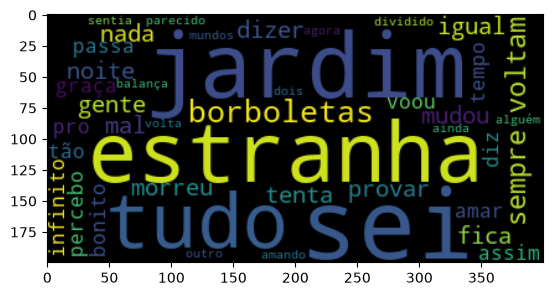

In [51]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(stopwords=stopwords_pt).generate(letra_simplificada)
plt.imshow(wordcloud, interpolation='bilinear')
plt.show()

# Analizando o sentimento da letra

In [52]:
!pip install transformers torch sentencepiece

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
from transformers import pipeline

classificador = pipeline(
    "sentiment-analysis",
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student"
)

sentimento = classificador(letra_simplificada)
print(sentimento)

C:\Users\PROG01\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\PROG01\.cache\huggingface\hub\models--lxyuan--distilbert-base-multilingual-cased-sentiments-student. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7364.8

[{'label': 'negative', 'score': 0.6033777594566345}]
